# Imports and Configuration

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import GroupKFold, StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import roc_auc_score
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import BayesianRidge

# Models
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation
import xgboost as xgb
import catboost as cb
from catboost import CatBoostClassifier, Pool
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Utilities
from scipy.stats import rankdata
import gc

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Paths
COMP_PATH = "/kaggle/input/playground-series-s5e5"
ORIG_PATH = "/kaggle/input/f1-strategy-dataset-pit-stop-prediction"

TRAIN_PATH  = os.path.join(COMP_PATH, "train.csv")
TEST_PATH   = os.path.join(COMP_PATH, "test.csv")
SUB_PATH    = os.path.join(COMP_PATH, "sample_submission.csv")
ORIG_PATH_F = os.path.join(ORIG_PATH, "f1_strategy_dataset_v4.csv")

# Cross-Validation Config
N_FOLDS     = 5
TARGET      = "PitNextLap"
ORIG_WEIGHT = 0.7

# Softer compounds degrade faster → lower laps before pit
COMPOUND_ORDER = {
    "WET"          : 0,
    "INTERMEDIATE" : 1,
    "SOFT"         : 2,
    "MEDIUM"       : 3,
    "HARD"         : 4,
}

# LightGBM Params
LGB_PARAMS = {
    "objective"         : "binary",
    "metric"            : "auc",
    "learning_rate"     : 0.018446,  
    "num_leaves"        : 210,
    "max_depth"         : 11,
    "min_child_samples" : 37,
    "feature_fraction"  : 0.352,   
    "bagging_fraction"  : 0.776,   
    "bagging_freq"      : 2,
    "lambda_l1"         : 0.00947,  
    "lambda_l2"         : 2.2393,  
    "verbose"           : -1,
    "seed"              : SEED,
    "n_jobs"            : -1,
}

# XGBoost Params
XGB_PARAMS = {
    "objective"        : "binary:logistic",
    "eval_metric"      : "auc",
    "tree_method"      : "hist",
    "random_state"     : SEED,
    "learning_rate"    : 0.012813,
    "max_depth"        : 11,
    "min_child_weight" : 10,
    "colsample_bytree" : 0.2896,
    "subsample"        : 0.8737,
    "reg_alpha"        : 0.0000001289, 
    "reg_lambda"       : 0.0001042,
}

# CatBoost Params
CB_PARAMS = {
    "iterations"       : 2000,
    "learning_rate"    : 0.05,
    "depth"            : 7,
    "eval_metric"      : "AUC",
    "random_seed"      : SEED,
    "early_stopping_rounds": 100,
    "verbose"          : 200,
    "task_type"        : "CPU",
}

print("All imports loaded successfully.")
print(f"   LightGBM  v{lgb.__version__}")
print(f"   XGBoost   v{xgb.__version__}")
print(f"   CatBoost  v{cb.__version__}")

All imports loaded successfully.
   LightGBM  v4.6.0
   XGBoost   v3.2.0
   CatBoost  v1.2.10


# Load Data + Merge Original

In [2]:
# Load Competition Files
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/test.csv')
sub   = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv')

print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}")

# Load Original Dataset
orig = pd.read_csv('/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv')
print(f"Orig  shape (raw) : {orig.shape}")

# Align Original to Competition Schema
orig.drop(columns=["Normalized_TyreLife"], inplace=True, errors="ignore")
orig["id"] = -1
orig = orig[[c for c in train.columns if c in orig.columns]]

# Compound has NaN rows — drop them, then cast to str
print(f"\nOrig nulls before clean :\n{orig.isnull().sum()[orig.isnull().sum() > 0]}")

orig.dropna(subset=["Compound"], inplace=True)
orig["Compound"] = orig["Compound"].astype(str).str.strip().str.upper()

# Cast all string columns to consistent str type
for col in ["Driver", "Race", "Compound"]:
    orig[col]  = orig[col].astype(str).str.strip()
    train[col] = train[col].astype(str).str.strip()
    test[col]  = test[col].astype(str).str.strip()

print(f"Orig  shape (clean) : {orig.shape}")

print(f"\nCompound values — Train : {sorted(train['Compound'].unique())}")
print(f"Compound values — Orig  : {sorted(orig['Compound'].unique())}")
print(f"\nYear range — Train : {train['Year'].min()}–{train['Year'].max()}")
print(f"Year range — Orig  : {orig['Year'].min()}–{orig['Year'].max()}")

print("\n── Target Distribution ──")
print(f"  Train : {train[TARGET].value_counts(normalize=True).round(3).to_dict()}")
print(f"  Orig  : {orig[TARGET].value_counts(normalize=True).round(3).to_dict()}")

train["is_orig"] = 0
orig["is_orig"]  = 1

# Combine Train + Original
all_train = pd.concat([train, orig], axis=0, ignore_index=True)

print(f"\nCombined train shape  : {all_train.shape}")
print(f"Competition rows : {(all_train['is_orig']==0).sum():,}")
print(f"Original rows    : {(all_train['is_orig']==1).sum():,}")

all_train["sample_weight"] = np.where(
    all_train["is_orig"] == 1, ORIG_WEIGHT, 1.0
)

print(f"\nMissing values in all_train : {all_train.isnull().sum().sum()}")
print(f"Missing values in test      : {test.isnull().sum().sum()}")

print("\nData loaded and merged successfully.")

Train shape : (439140, 16)
Test  shape : (188165, 15)
Orig  shape (raw) : (101371, 16)

Orig nulls before clean :
Compound    66
dtype: int64
Orig  shape (clean) : (101305, 16)

Compound values — Train : ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT', 'WET']
Compound values — Orig  : ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT', 'WET']

Year range — Train : 2022–2025
Year range — Orig  : 2022–2025

── Target Distribution ──
  Train : {0.0: 0.801, 1.0: 0.199}
  Orig  : {0: 0.745, 1: 0.255}

Combined train shape  : (540445, 17)
Competition rows : 439,140
Original rows    : 101,305

Missing values in all_train : 0
Missing values in test      : 0

Data loaded and merged successfully.


# Feature Engineering

In [3]:
# Mark test rows, concat
test["is_orig"]       = 0
test["sample_weight"] = 1.0
test[TARGET]          = np.nan

combined = pd.concat([all_train, test], axis=0, ignore_index=True)
print(f"Combined (train+test) shape: {combined.shape}")

Combined (train+test) shape: (728610, 18)


## Compound Ordinal Encoding

In [4]:
combined["Compound_ord"] = combined["Compound"].map(COMPOUND_ORDER)

## Race + Year Group Key

In [5]:
combined["RaceYear"] = combined["Race"] + "_" + combined["Year"].astype(str)

## Total Laps per Race (derived from RaceProgress)

In [6]:
combined["TotalLaps_est"] = (
    combined["LapNumber"] / combined["RaceProgress"].replace(0, np.nan)
).round()

combined["LapsRemaining"] = combined["TotalLaps_est"] - combined["LapNumber"]

## Tyre × Compound Interaction

In [7]:
# 15 laps on SOFT ≠ 15 laps on HARD
combined["TyreLife_x_Compound"] = combined["TyreLife"] * combined["Compound_ord"]

# Expected max stint length per compound (domain knowledge)
COMPOUND_MAX_STINT = {
    "SOFT"         : 25,
    "MEDIUM"       : 35,
    "HARD"         : 50,
    "INTERMEDIATE" : 30,
    "WET"          : 40,
}
combined["MaxStint"] = combined["Compound"].map(COMPOUND_MAX_STINT)
combined["TyrePct_Used"] = combined["TyreLife"] / combined["MaxStint"]  # 0→1+ scale
combined["TyrePct_Used"] = combined["TyrePct_Used"].clip(0, 2)          # cap outliers

## Race Stage Flags

In [8]:
# Undercut window: laps 20-40% and 55-75% are classic pit windows
combined["InPitWindow"]  = (
    ((combined["RaceProgress"] >= 0.20) & (combined["RaceProgress"] <= 0.40)) |
    ((combined["RaceProgress"] >= 0.55) & (combined["RaceProgress"] <= 0.75))
).astype(int)

## Interaction Features

In [9]:
# Sort by driver + race + lap so rolling windows are temporal
combined.sort_values(["Driver", "RaceYear", "LapNumber"], inplace=True)
combined.reset_index(drop=True, inplace=True)

grp = combined.groupby(["Driver", "RaceYear"])

# Old tyres + late race = THE core pit trigger
combined["TyreLife_x_RaceProgress"] = (
    combined["TyreLife"] * combined["RaceProgress"]
)

# How fast are tyres degrading per lap?
combined["Degradation_per_Lap"] = (
    combined["Cumulative_Degradation"] / combined["TyreLife"].replace(0, 1)
).clip(0, 10)

# Strategic ratio: can we physically make it to the end?
combined["TyreLife_vs_LapsRemaining"] = (
    combined["TyreLife"] / combined["LapsRemaining"].replace(0, 1)
).clip(0, 10)

# Stint aggression: high stint number on soft compound = dangerous
combined["Stint_x_Compound"] = combined["Stint"] * combined["Compound_ord"]

# Raw distance to optimal stint end
combined["LapsOverMaxStint"] = (
    combined["TyreLife"] - combined["MaxStint"]
).clip(-50, 50)

## Group-Based Rolling Features

In [10]:
# Rolling 3-lap mean of LapTime — smoothed pace
combined["LapTime_roll3"]  = (
    grp["LapTime (s)"].transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Rolling 3-lap mean of LapTime_Delta — degradation trend
combined["Delta_roll3"]    = (
    grp["LapTime_Delta"].transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Rolling 3-lap mean of Cumulative_Degradation
combined["CumDeg_roll3"]   = (
    grp["Cumulative_Degradation"].transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Lap-over-lap LapTime change (sudden slowdown = tyre cliff)
combined["LapTime_diff1"]  = (
    grp["LapTime (s)"].transform(lambda x: x.diff(1))
)

## Extended Rolling Windows

In [11]:
combined["LapTime_roll5"]  = (
    grp["LapTime (s)"].transform(lambda x: x.rolling(5,  min_periods=1).mean())
)
combined["Delta_roll5"]    = (
    grp["LapTime_Delta"].transform(lambda x: x.rolling(5,  min_periods=1).mean())
)
combined["LapTime_roll10"] = (
    grp["LapTime (s)"].transform(lambda x: x.rolling(10, min_periods=1).mean())
)
combined["Delta_roll10"]   = (
    grp["LapTime_Delta"].transform(lambda x: x.rolling(10, min_periods=1).mean())
)

# Pace dropoff: recent 3-lap avg vs longer 10-lap avg
# Positive value = getting slower = tyre cliff signal
combined["PaceDropoff_3v10"] = (
    combined["LapTime_roll3"] - combined["LapTime_roll10"]
)
combined["DegDropoff_3v10"]  = (
    combined["Delta_roll3"] - combined["Delta_roll10"]
)

## Position-Based Features

In [12]:
combined["Position_x_Lap"]  = combined["Position"] * combined["RaceProgress"]

## Relative Pace Features

In [13]:
# Median Lap Time for the Field (Are they slower than everyone else THIS lap?)
combined["Field_Median_LapTime"] = combined.groupby(["RaceYear", "LapNumber"])["LapTime (s)"].transform("median")
combined["Pace_vs_Field"] = combined["LapTime (s)"] - combined["Field_Median_LapTime"]

# Track Position Dynamics (Are they stuck behind someone?)
combined.sort_values(["RaceYear", "LapNumber", "Position"], inplace=True)
combined["Pace_vs_Car_Ahead"] = combined.groupby(["RaceYear", "LapNumber"])["LapTime (s)"].diff().fillna(0)

# Mandatory Pit Stop Rule
combined["Must_Pit_Soon"] = ((combined["Stint"] == 1) & (combined["RaceProgress"] > 0.85)).astype(int)

# Re-sort back to the original time-series format
combined.sort_values(["Driver", "RaceYear", "LapNumber"], inplace=True)
combined.reset_index(drop=True, inplace=True)

# Tyre Cliff Indicator (Use the chronologically safe LapTime_diff1 we made earlier!)
combined["Is_Tyre_Cliff"] = (combined["LapTime_diff1"] > 2.0).astype(int)

## Pit wall Strategy

In [14]:
# Delta to Personal Best
combined["Personal_Best_Lap"] = combined.groupby(["Driver", "RaceYear", "Stint"])["LapTime (s)"].cummin()
combined["Delta_to_Personal_Best"] = combined["LapTime (s)"] - combined["Personal_Best_Lap"]

# Track Degradation Index 
combined["Track_Compound_Severity"] = combined.groupby(["RaceYear", "Compound"])["Cumulative_Degradation"].transform("median")

# Relative Tyre Age 
combined["Field_Median_TyreLife"] = combined.groupby(["RaceYear", "LapNumber"])["TyreLife"].transform("median")
combined["Relative_Tyre_Age"] = combined["TyreLife"] - combined["Field_Median_TyreLife"]

# The Pit Frenzy (Undercut / Chain Reaction Tracker)
pitted_last_lap = combined.groupby(["RaceYear", "LapNumber"])["PitStop"].sum().reset_index()
pitted_last_lap["LapNumber"] += 1 
pitted_last_lap.rename(columns={"PitStop": "Cars_Pitted_Last_Lap"}, inplace=True)

combined = combined.merge(pitted_last_lap, on=["RaceYear", "LapNumber"], how="left")
combined["Cars_Pitted_Last_Lap"] = combined["Cars_Pitted_Last_Lap"].fillna(0)

# Re-sort to maintain chronological integrity
combined.sort_values(["Driver", "RaceYear", "LapNumber"], inplace=True)
combined.reset_index(drop=True, inplace=True)

## Fill any NaNs created by rolling/diff

In [15]:
roll_cols = [
    "LapTime_roll3", "Delta_roll3", "CumDeg_roll3", "LapTime_diff1",
    "LapTime_roll5", "Delta_roll5", "LapTime_roll10", "Delta_roll10",
    "PaceDropoff_3v10", "DegDropoff_3v10",
    "TotalLaps_est", "LapsRemaining",
    "Degradation_per_Lap", "TyreLife_vs_LapsRemaining",
    "LapsOverMaxStint",
]
combined[roll_cols] = combined[roll_cols].fillna(0)

## Split back into train / test

In [16]:
train_fe = combined[combined[TARGET].notna()].copy()
test_fe  = combined[combined[TARGET].isna()].copy()

print(f"\ntrain_fe shape : {train_fe.shape}")
print(f"test_fe  shape : {test_fe.shape}")


train_fe shape : (540445, 53)
test_fe  shape : (188165, 53)


## Target Encoding

In [17]:
TARGET_ENC_COLS = ["Driver", "Race", "RaceYear", "Compound"]
SMOOTH = 20
global_mean = train_fe[TARGET].mean()

# Initialize columns
for col in TARGET_ENC_COLS:
    train_fe[f"TE_{col}"] = 0.0
    test_fe[f"TE_{col}"] = 0.0

temp_sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

for tr_idx, val_idx in temp_sgkf.split(train_fe, train_fe[TARGET], train_fe["RaceYear"]):
    tr_df = train_fe.iloc[tr_idx]
    val_df = train_fe.iloc[val_idx]
    
    for col in TARGET_ENC_COLS:
        agg = tr_df.groupby(col)[TARGET].agg(["mean", "count"])
        agg["te_smooth"] = (agg["count"] * agg["mean"] + SMOOTH * global_mean) / (agg["count"] + SMOOTH)
        
        # Map to validation fold
        train_fe.loc[train_fe.index[val_idx], f"TE_{col}"] = val_df[col].map(agg["te_smooth"]).fillna(global_mean)
        
        # Map to test set (accumulating across folds)
        test_fe[f"TE_{col}"] += test_fe[col].map(agg["te_smooth"]).fillna(global_mean) / N_FOLDS

print("Proper OOF Target Encoding complete.")

Proper OOF Target Encoding complete.


## Features

In [18]:
FEATURES = [
    # Raw numerics
    "Year", "LapNumber", "Stint", "TyreLife", "Position",
    "LapTime (s)", "LapTime_Delta", "Cumulative_Degradation",
    "RaceProgress", "Position_Change", "PitStop",
    # Tyre features
    "Compound_ord", "TyreLife_x_Compound", "TyrePct_Used", "MaxStint",
    "TotalLaps_est", "LapsRemaining",
    # Interaction features
    "TyreLife_x_RaceProgress", "Degradation_per_Lap",
    "TyreLife_vs_LapsRemaining", "Stint_x_Compound", "LapsOverMaxStint",
    # Race stage
    "InPitWindow",
    # Rolling windows
    "LapTime_roll3", "Delta_roll3", "CumDeg_roll3", "LapTime_diff1",
    "LapTime_roll5", "Delta_roll5",
    "LapTime_roll10", "Delta_roll10",
    "PaceDropoff_3v10", "DegDropoff_3v10",
    # Position
    "Position_x_Lap",
    # Encodings
    "TE_Driver", "TE_Race", "TE_Compound", "TE_RaceYear",
    # Relative Pace
    "Pace_vs_Field", "Pace_vs_Car_Ahead", "Must_Pit_Soon", "Is_Tyre_Cliff",
    # Pit Wall Strategy
    "Delta_to_Personal_Best", "Track_Compound_Severity", "Relative_Tyre_Age", "Cars_Pitted_Last_Lap",
]  

print(f"\nTotal features: {len(FEATURES)}")


Total features: 46


## Null Check

In [19]:
null_check = train_fe[FEATURES].isnull().sum()
if null_check.sum() == 0:
    print("\nNo nulls in feature matrix.")
else:
    print("\nNulls found:")
    print(null_check[null_check > 0])


No nulls in feature matrix.


# LightGBM

  LightGBM — 5-Fold GroupKFold (by Year)
[500]	valid_0's auc: 0.909908
[1000]	valid_0's auc: 0.910815

  Fold 1 │ Calibrated AUC: 0.91114 │ Best iter: 867
[500]	valid_0's auc: 0.884275
[1000]	valid_0's auc: 0.885735

  Fold 2 │ Calibrated AUC: 0.88616 │ Best iter: 978
[500]	valid_0's auc: 0.934068
[1000]	valid_0's auc: 0.934422

  Fold 3 │ Calibrated AUC: 0.93481 │ Best iter: 944
[500]	valid_0's auc: 0.943657
[1000]	valid_0's auc: 0.944737

  Fold 4 │ Calibrated AUC: 0.94515 │ Best iter: 1054
[500]	valid_0's auc: 0.940014
[1000]	valid_0's auc: 0.940339

  Fold 5 │ Calibrated AUC: 0.94066 │ Best iter: 936

  LightGBM OOF AUC : 0.92705
  Per-fold AUCs    : [np.float64(0.91114), np.float64(0.88616), np.float64(0.93481), np.float64(0.94515), np.float64(0.94066)]
  Std dev          : 0.02208


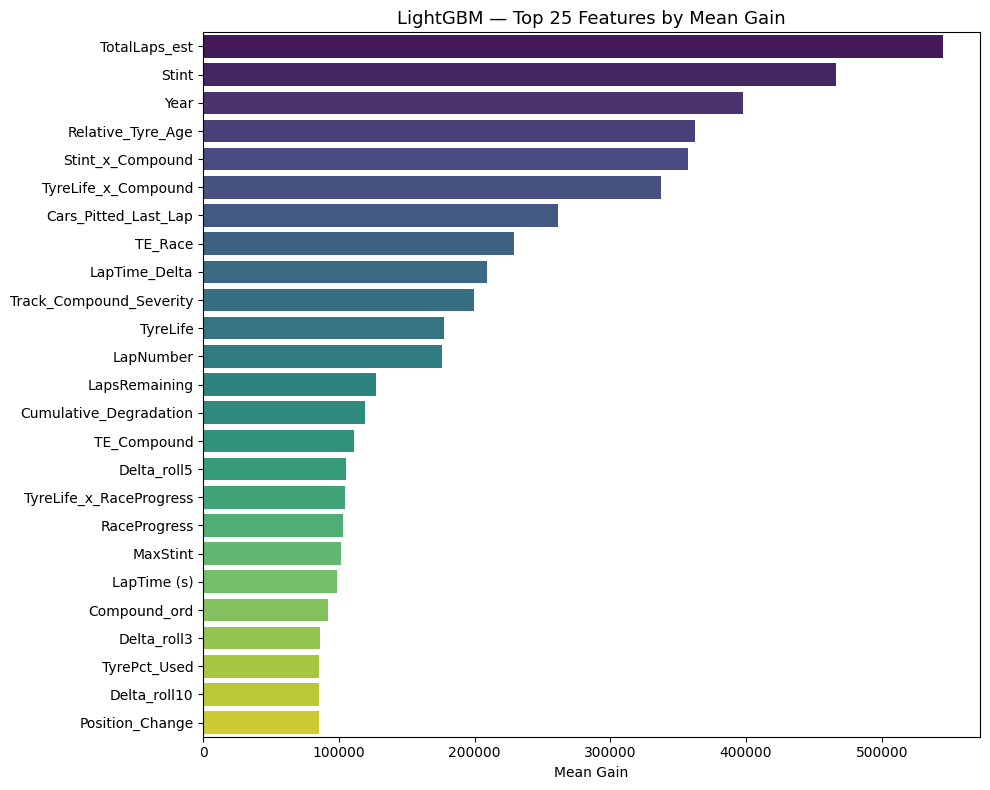


LightGBM training complete.
   OOF array  shape : (540445,)
   Test preds shape : (188165,)


In [20]:
X      = train_fe[FEATURES].values
y      = train_fe[TARGET].values.astype(int)
w      = train_fe["sample_weight"].values
groups = train_fe["RaceYear"].values 

X_test = test_fe[FEATURES].values

oof_lgb  = np.zeros(len(X))                  # out-of-fold predictions
test_lgb = np.zeros(len(X_test))             # averaged test predictions
fold_auc = []
feature_importance_list = []

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

print("=" * 60)
print(f"  LightGBM — {N_FOLDS}-Fold GroupKFold (by Year)")
print("=" * 60)

for fold, (tr_idx, val_idx) in enumerate(sgkf.split(X, y, groups), 1):

    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    w_tr        = w[tr_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr, weight=w_tr,
                         feature_name=FEATURES)
    dvalid = lgb.Dataset(X_val, label=y_val,
                         feature_name=FEATURES, reference=dtrain)

    model = lgb.train(
        LGB_PARAMS,   
        dtrain,
        num_boost_round        = 8000,
        valid_sets             = [dvalid],
        callbacks              = [
            early_stopping(stopping_rounds=150, verbose=False),
            log_evaluation(period=500),
        ],
    )

    raw_val_preds = model.predict(X_val)
    raw_test_preds = model.predict(X_test)
    
    calibrator = IsotonicRegression(out_of_bounds='clip')
    calibrator.fit(raw_val_preds, y_val)
    
    oof_lgb[val_idx] = calibrator.predict(raw_val_preds)
    test_lgb += calibrator.predict(raw_test_preds) / N_FOLDS

    auc = roc_auc_score(y_val, oof_lgb[val_idx])
    fold_auc.append(auc)
    print(f"\n  Fold {fold} │ Calibrated AUC: {auc:.5f} │ Best iter: {model.best_iteration}")

    fi = pd.DataFrame({
        "feature"   : FEATURES,
        "importance": model.feature_importance(importance_type="gain"),
        "fold"      : fold,
    })
    feature_importance_list.append(fi)

    del X_tr, X_val, y_tr, y_val, dtrain, dvalid
    gc.collect()

oof_auc_lgb = roc_auc_score(y, oof_lgb)

print("\n" + "=" * 60)
print(f"  LightGBM OOF AUC : {oof_auc_lgb:.5f}")
print(f"  Per-fold AUCs    : {[round(a,5) for a in fold_auc]}")
print(f"  Std dev          : {np.std(fold_auc):.5f}")
print("=" * 60)

# Feature Importance Plot
fi_df = (
    pd.concat(feature_importance_list)
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 8))
sns.barplot(data=fi_df.head(25), x="importance", y="feature",
            palette="viridis")
plt.title("LightGBM — Top 25 Features by Mean Gain", fontsize=13)
plt.xlabel("Mean Gain")
plt.ylabel("")
plt.tight_layout()
plt.show()

print("\nLightGBM training complete.")
print(f"   OOF array  shape : {oof_lgb.shape}")
print(f"   Test preds shape : {test_lgb.shape}")

# XGBoost

  XGBoost — 5-Fold GroupKFold (by Year)
[0]	val-auc:0.82399
[200]	val-auc:0.90156
[400]	val-auc:0.90661
[600]	val-auc:0.90892
[800]	val-auc:0.91006
[1000]	val-auc:0.91046
[1200]	val-auc:0.91078
[1400]	val-auc:0.91095
[1547]	val-auc:0.91094

  Fold 1 │ Calibrated AUC: 0.91116 │ Best iter: 1447
[0]	val-auc:0.76254
[200]	val-auc:0.87299
[400]	val-auc:0.88025
[600]	val-auc:0.88284
[800]	val-auc:0.88398
[1000]	val-auc:0.88449
[1200]	val-auc:0.88463
[1400]	val-auc:0.88474
[1412]	val-auc:0.88471

  Fold 2 │ Calibrated AUC: 0.88509 │ Best iter: 1312
[0]	val-auc:0.89289
[200]	val-auc:0.92990
[400]	val-auc:0.93237
[600]	val-auc:0.93318
[800]	val-auc:0.93358
[965]	val-auc:0.93356

  Fold 3 │ Calibrated AUC: 0.93389 │ Best iter: 865
[0]	val-auc:0.85182
[200]	val-auc:0.93797
[400]	val-auc:0.94247
[600]	val-auc:0.94430
[800]	val-auc:0.94512
[1000]	val-auc:0.94542
[1200]	val-auc:0.94563
[1400]	val-auc:0.94565
[1432]	val-auc:0.94567

  Fold 4 │ Calibrated AUC: 0.94600 │ Best iter: 1332
[0]	val-auc:0.8

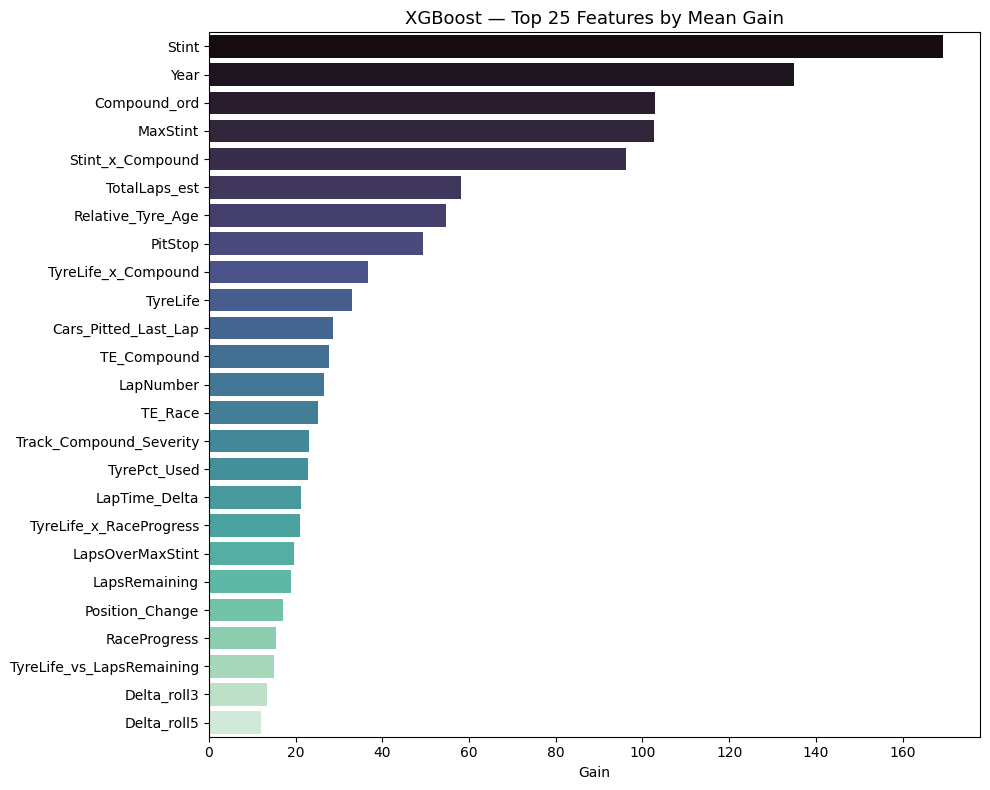


XGBoost training complete.
   OOF array  shape : (540445,)
   Test preds shape : (188165,)


In [21]:
oof_xgb  = np.zeros(len(X))
test_xgb = np.zeros(len(X_test))
fold_auc_xgb = []

print("=" * 60)
print(f"  XGBoost — {N_FOLDS}-Fold GroupKFold (by Year)")
print("=" * 60)

for fold, (tr_idx, val_idx) in enumerate(sgkf.split(X, y, groups), 1):

    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    w_tr        = w[tr_idx]

    dtrain = xgb.DMatrix(X_tr, label=y_tr, weight=w_tr,
                         feature_names=FEATURES)
    dvalid = xgb.DMatrix(X_val, label=y_val,
                         feature_names=FEATURES)
    dtest  = xgb.DMatrix(X_test, feature_names=FEATURES)

    model = xgb.train(
        XGB_PARAMS,
        dtrain,
        num_boost_round      = 3000,
        evals                = [(dvalid, "val")],
        early_stopping_rounds= 100,
        verbose_eval         = 200,
    )

    raw_val_preds = model.predict(dvalid)
    raw_test_preds = model.predict(dtest)
    
    calibrator = IsotonicRegression(out_of_bounds='clip')
    calibrator.fit(raw_val_preds, y_val)
    
    oof_xgb[val_idx] = calibrator.predict(raw_val_preds)
    test_xgb += calibrator.predict(raw_test_preds) / N_FOLDS

    auc = roc_auc_score(y_val, oof_xgb[val_idx])
    fold_auc_xgb.append(auc)
    print(f"\n  Fold {fold} │ Calibrated AUC: {auc:.5f} │ Best iter: {model.best_iteration}")

    del X_tr, X_val, y_tr, y_val, dtrain, dvalid, dtest
    gc.collect()

# OOF Score
oof_auc_xgb = roc_auc_score(y, oof_xgb)

print("\n" + "=" * 60)
print(f"  XGBoost OOF AUC : {oof_auc_xgb:.5f}")
print(f"  Per-fold AUCs   : {[round(a,5) for a in fold_auc_xgb]}")
print(f"  Std dev         : {np.std(fold_auc_xgb):.5f}")
print("=" * 60)

# Feature Importance Plot
fi_xgb = (
    pd.Series(model.get_score(importance_type="gain"))
    .sort_values(ascending=False)
    .head(25)
    .reset_index()
)
fi_xgb.columns = ["feature", "importance"]

plt.figure(figsize=(10, 8))
sns.barplot(data=fi_xgb, x="importance", y="feature", palette="mako")
plt.title("XGBoost — Top 25 Features by Mean Gain", fontsize=13)
plt.xlabel("Gain")
plt.ylabel("")
plt.tight_layout()
plt.show()

print("\nXGBoost training complete.")
print(f"   OOF array  shape : {oof_xgb.shape}")
print(f"   Test preds shape : {test_xgb.shape}")

# CatBoost

  CatBoost — 5-Fold StratifiedGroupKFold (by RaceYear)
0:	test: 0.8745041	best: 0.8745041 (0)	total: 188ms	remaining: 6m 15s
200:	test: 0.9035320	best: 0.9035320 (200)	total: 21.3s	remaining: 3m 10s
400:	test: 0.9061887	best: 0.9061891 (385)	total: 42s	remaining: 2m 47s
600:	test: 0.9064483	best: 0.9064840 (565)	total: 1m 2s	remaining: 2m 24s
800:	test: 0.9073141	best: 0.9073191 (796)	total: 1m 22s	remaining: 2m 3s
1000:	test: 0.9081745	best: 0.9082511 (979)	total: 1m 42s	remaining: 1m 42s
1200:	test: 0.9084991	best: 0.9085490 (1179)	total: 2m 2s	remaining: 1m 21s
1400:	test: 0.9088035	best: 0.9088059 (1387)	total: 2m 22s	remaining: 1m 1s
1600:	test: 0.9089669	best: 0.9090005 (1589)	total: 2m 43s	remaining: 40.6s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9090608029
bestIteration = 1640

Shrink model to first 1641 iterations.

  Fold 1 │ Calibrated AUC: 0.90930 │ Best iter: 1640
0:	test: 0.8359162	best: 0.8359162 (0)	total: 130ms	remaining: 4m 20s
200:	test: 0

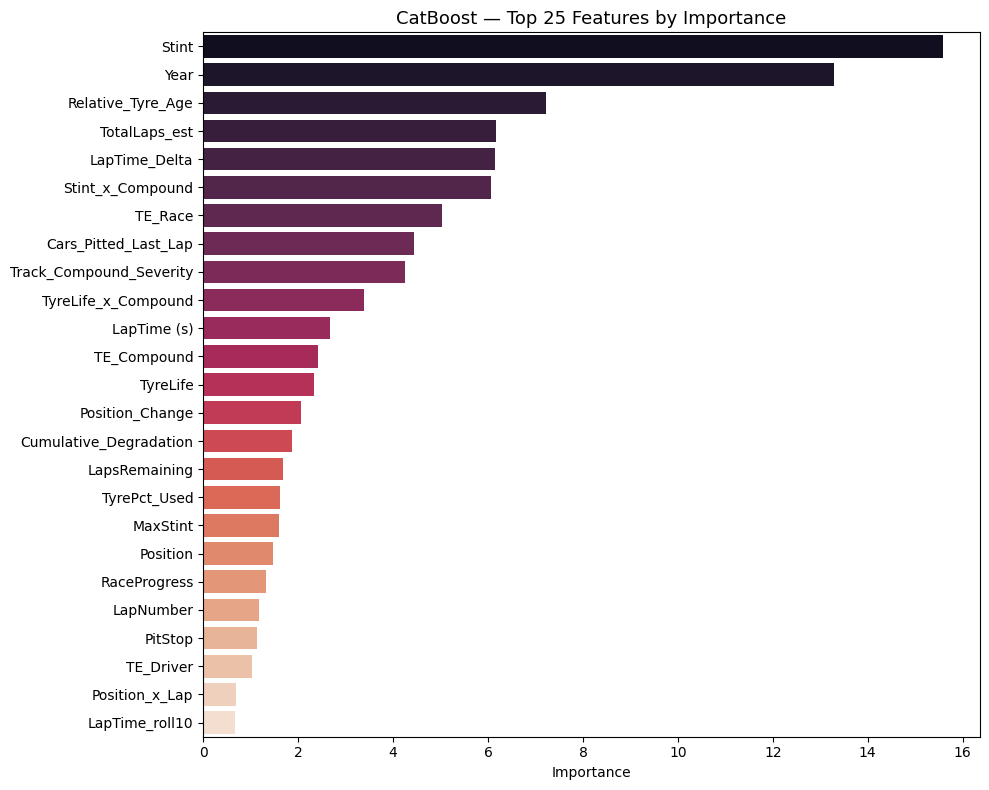


CatBoost training complete.
   OOF array  shape : (540445,)
   Test preds shape : (188165,)


In [22]:
oof_cb      = np.zeros(len(X))
test_cb     = np.zeros(len(X_test))
fold_auc_cb = []

print("=" * 60)
print(f"  CatBoost — {N_FOLDS}-Fold StratifiedGroupKFold (by RaceYear)")
print("=" * 60)

for fold, (tr_idx, val_idx) in enumerate(sgkf.split(X, y, groups), 1):

    X_tr  = X[tr_idx]
    X_val = X[val_idx]
    y_tr  = y[tr_idx]
    y_val = y[val_idx]
    w_tr  = w[tr_idx]

    train_pool = Pool(X_tr, label=y_tr, weight=w_tr)
    valid_pool = Pool(X_val, label=y_val)
    test_pool  = Pool(X_test)

    model = CatBoostClassifier(**CB_PARAMS)
    model.fit(
        train_pool,
        eval_set=valid_pool,
        use_best_model=True,
    )

    raw_val_preds = model.predict_proba(valid_pool)[:, 1]
    raw_test_preds = model.predict_proba(test_pool)[:, 1]
    
    calibrator = IsotonicRegression(out_of_bounds='clip')
    calibrator.fit(raw_val_preds, y_val)
    
    oof_cb[val_idx] = calibrator.predict(raw_val_preds)
    test_cb += calibrator.predict(raw_test_preds) / N_FOLDS

    auc = roc_auc_score(y_val, oof_cb[val_idx])
    fold_auc_cb.append(auc)
    print(f"\n  Fold {fold} │ Calibrated AUC: {auc:.5f} │ Best iter: {model.best_iteration_}")

    del X_tr, X_val, y_tr, y_val, train_pool, valid_pool, test_pool
    gc.collect()

oof_auc_cb = roc_auc_score(y, oof_cb)

print("\n" + "=" * 60)
print(f"  CatBoost OOF AUC : {oof_auc_cb:.5f}")
print(f"  Per-fold AUCs    : {[round(a,5) for a in fold_auc_cb]}")
print(f"  Std dev          : {np.std(fold_auc_cb):.5f}")
print("=" * 60)

fi_cb = (
    pd.DataFrame({
        "feature"   : FEATURES,
        "importance": model.get_feature_importance(),
    })
    .sort_values("importance", ascending=False)
    .head(25)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=fi_cb, x="importance", y="feature", palette="rocket")
plt.title("CatBoost — Top 25 Features by Importance", fontsize=13)
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

print("\nCatBoost training complete.")
print(f"   OOF array  shape : {oof_cb.shape}")
print(f"   Test preds shape : {test_cb.shape}")

# Tabular ResNet

In [23]:
class TabularResNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        
        # Initial projection
        self.proj = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU()
        )
        
        # Residual Block 1
        self.res1 = nn.Sequential(
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256)
        )
        
        # Residual Block 2 (Compressing)
        self.res2_proj = nn.Linear(256, 128)
        self.res2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 128),
            nn.BatchNorm1d(128)
        )
        
        # Final output
        self.out = nn.Sequential(
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Initial layer
        x = self.proj(x)
        
        # First Skip Connection
        x = nn.functional.relu(x + self.res1(x))
        
        # Second Skip Connection (with projection to match sizes)
        x = nn.functional.relu(self.res2_proj(x) + self.res2(x))
        
        # Output
        return self.out(x).squeeze()

oof_mlp  = np.zeros(len(X))
test_mlp = np.zeros(len(X_test))
fold_auc_mlp = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("=" * 60)
print(f"  Tabular ResNet — {N_FOLDS}-Fold StratifiedGroupKFold (by RaceYear)")
print("=" * 60)

for fold, (tr_idx, val_idx) in enumerate(sgkf.split(X, y, groups), 1):

    X_tr_raw  = X[tr_idx]
    X_val_raw = X[val_idx]
    
    scaler = StandardScaler()
    X_tr  = scaler.fit_transform(X_tr_raw)
    X_val = scaler.transform(X_val_raw)
    X_test_scaled_fold = scaler.transform(X_test)
    
    y_tr  = y[tr_idx].astype(np.float32)
    y_val = y[val_idx].astype(np.float32)
    w_tr  = w[tr_idx].astype(np.float32)

    train_dataset = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.float32),
        torch.tensor(w_tr, dtype=torch.float32),
    )
    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32),
    )
    test_dataset = TensorDataset(
        torch.tensor(X_test_scaled_fold, dtype=torch.float32),
    )

    train_loader = DataLoader(train_dataset, batch_size=4096, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=4096, shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=4096, shuffle=False)

    model_mlp = TabularResNet(input_dim=X_tr.shape[1]).to(device)
    
    optimizer  = torch.optim.AdamW(model_mlp.parameters(), lr=1e-3, weight_decay=1e-5)
    criterion  = nn.BCELoss(reduction="none")
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=20, eta_min=1e-5)

    best_auc_mlp  = 0
    best_state    = None

    for epoch in range(20):
        model_mlp.train()
        for batch_x, batch_y, batch_w in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            batch_w = batch_w.to(device)
            optimizer.zero_grad()
            preds = model_mlp(batch_x)
            loss  = (criterion(preds, batch_y) * batch_w).mean()
            loss.backward()
            optimizer.step()
        scheduler.step()

        model_mlp.eval()
        val_preds = []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(device)
                val_preds.extend(model_mlp(batch_x).cpu().numpy())

        auc = roc_auc_score(y_val, val_preds)
        if auc > best_auc_mlp:
            best_auc_mlp = auc
            best_state   = {k: v.clone() for k, v in model_mlp.state_dict().items()}

    model_mlp.load_state_dict(best_state)
    model_mlp.eval()

    val_preds_final = []
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            val_preds_final.extend(model_mlp(batch_x).cpu().numpy())
    oof_mlp[val_idx] = val_preds_final

    test_preds_fold = []
    with torch.no_grad():
        for (batch_x,) in test_loader:
            batch_x = batch_x.to(device)
            test_preds_fold.extend(model_mlp(batch_x).cpu().numpy())
    test_mlp += np.array(test_preds_fold) / N_FOLDS

    auc = roc_auc_score(y_val, oof_mlp[val_idx])
    fold_auc_mlp.append(auc)
    print(f"\n  Fold {fold} │ AUC: {auc:.5f} │ Best epoch AUC: {best_auc_mlp:.5f}")

    del model_mlp, train_dataset, val_dataset
    gc.collect()

oof_auc_mlp = roc_auc_score(y, oof_mlp)
print("\n" + "=" * 60)
print(f"  Tabular ResNet OOF AUC : {oof_auc_mlp:.5f}")
print(f"  Per-fold    : {[round(a,5) for a in fold_auc_mlp]}")
print(f"  Std dev     : {np.std(fold_auc_mlp):.5f}")
print("=" * 60)
print("\nNeural Network training complete.")

Using device: cpu
  Tabular ResNet — 5-Fold StratifiedGroupKFold (by RaceYear)

  Fold 1 │ AUC: 0.90219 │ Best epoch AUC: 0.90219

  Fold 2 │ AUC: 0.87235 │ Best epoch AUC: 0.87235

  Fold 3 │ AUC: 0.91986 │ Best epoch AUC: 0.91986

  Fold 4 │ AUC: 0.92646 │ Best epoch AUC: 0.92646

  Fold 5 │ AUC: 0.92869 │ Best epoch AUC: 0.92869

  Tabular ResNet OOF AUC : 0.91259
  Per-fold    : [np.float64(0.90219), np.float64(0.87235), np.float64(0.91986), np.float64(0.92646), np.float64(0.92869)]
  Std dev     : 0.02096

Neural Network training complete.


# Model Comparison Table

In [24]:
print("\nModel Comparison")
comparison = pd.DataFrame({
    "Model"   : ["LightGBM", "XGBoost", "CatBoost", "Tabular ResNet"],
    "OOF AUC" : [oof_auc_lgb, oof_auc_xgb, oof_auc_cb, oof_auc_mlp],
    "Std Dev" : [np.std(fold_auc), np.std(fold_auc_xgb), np.std(fold_auc_cb), np.std(fold_auc_mlp)],
})
print(comparison.to_string(index=False))


Model Comparison
         Model  OOF AUC  Std Dev
      LightGBM   0.9271   0.0221
       XGBoost   0.9269   0.0226
      CatBoost   0.9243   0.0237
Tabular ResNet   0.9126   0.0210


# Stacking

In [25]:
print("=" * 60)
print("  STACKING META-LEARNER (Bayesian Ridge)")
print("=" * 60)

oof_stack  = np.column_stack([oof_lgb, oof_xgb, oof_cb, oof_mlp])
test_stack = np.column_stack([test_lgb, test_xgb, test_cb, test_mlp])

# Initialize Bayesian Ridge
meta_model = BayesianRidge()
meta_model.fit(oof_stack, y)
meta_oof = meta_model.predict(oof_stack)
meta_test_preds = meta_model.predict(test_stack)

# Bayesian Ridge is a Regressor, so it can occasionally predict slightly below 0 or above 1.
# We clip the probabilities to be absolutely safe for the Kaggle AUC metric
meta_oof = np.clip(meta_oof, 0.00001, 0.99999)
meta_test_preds = np.clip(meta_test_preds, 0.00001, 0.99999)

stacking_auc = roc_auc_score(y, meta_oof)
print(f"Stacking Meta-Learner OOF AUC : {stacking_auc:.5f}\n")

print("Meta-Learner Model Weights (Coefficients):")
print(f"  LightGBM       : {meta_model.coef_[0]:.4f}")
print(f"  XGBoost        : {meta_model.coef_[1]:.4f}")
print(f"  CatBoost       : {meta_model.coef_[2]:.4f}")
print(f"  Tabular ResNet : {meta_model.coef_[3]:.4f}")

  STACKING META-LEARNER (Bayesian Ridge)
Stacking Meta-Learner OOF AUC : 0.92796

Meta-Learner Model Weights (Coefficients):
  LightGBM       : 0.3305
  XGBoost        : 0.3764
  CatBoost       : 0.1399
  Tabular ResNet : 0.1640


# Final Results and Submission

In [26]:
test_fe_copy = test_fe[["id"]].copy()
test_fe_copy["PitNextLap"] = meta_test_preds
sub = test_fe_copy.sort_values("id").reset_index(drop=True)
sub.to_csv("/kaggle/working/submission.csv", index=False)

print("\nSubmission saved to /kaggle/working/submission.csv!")


Submission saved to /kaggle/working/submission.csv!
